credit card

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
!unzip

unzip:  cannot find or open /content/creditcard.csv.zip, /content/creditcard.csv.zip.zip or /content/creditcard.csv.zip.ZIP.


In [45]:
df=pd.read_csv("/content/creditcard.csv")
print(df)

        Time        V1         V2        V3        V4        V5        V6  \
0          0 -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...        ...       ...       ...       ...       ...   
33755  37372  0.597155  -1.457940  0.648770 -1.154721 -1.384692 -0.114190   
33756  37373 -7.504323 -15.633772 -4.215051  1.507090 -5.412604  3.243205   
33757  37373  1.242547   0.010297 -1.206012  0.083576  2.171891  3.391877   
33758  37373 -1.065865   1.177477  2.083773  1.296198  0.564073  0.295974   
33759  37373 -0.302250   0.828254 -0.311542 -1.108255  2.533421  3.274040   

             V7        V8        V9  ...       V21                  V22  \


/tmp/ipykernel_2747/216746050.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/creditcard.csv")


In [46]:
df.head()#using for reading files

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [47]:
df.info()#for getting details inshort

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33760 entries, 0 to 33759
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    33760 non-null  int64  
 1   V1      33760 non-null  float64
 2   V2      33760 non-null  float64
 3   V3      33760 non-null  float64
 4   V4      33760 non-null  float64
 5   V5      33760 non-null  float64
 6   V6      33760 non-null  float64
 7   V7      33760 non-null  float64
 8   V8      33760 non-null  float64
 9   V9      33760 non-null  float64
 10  V10     33760 non-null  float64
 11  V11     33760 non-null  float64
 12  V12     33760 non-null  float64
 13  V13     33760 non-null  float64
 14  V14     33760 non-null  float64
 15  V15     33760 non-null  float64
 16  V16     33760 non-null  float64
 17  V17     33760 non-null  float64
 18  V18     33760 non-null  float64
 19  V19     33760 non-null  float64
 20  V20     33760 non-null  float64
 21  V21     33760 non-null  float64
 22

In [48]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
33755,False
33756,False
33757,False
33758,False


In [49]:
print("number of coloum",df.shape[1])#to find no of column
print("number of rows",df.shape[0])#to find no of rows

number of coloum 31
number of rows 33760


In [50]:
df.duplicated().sum()#to find sum of duplicate values

np.int64(137)

In [51]:
df=df.drop_duplicates()

In [52]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
33755,False
33756,False
33757,False
33758,False


In [53]:
df["Amount"]

,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99
...,...
33755,300.00
33756,4476.72
33757,28.56
33758,0.00


In [54]:
sc=StandardScaler()

In [55]:
df['Amount']=sc.fit_transform(pd.DataFrame(df['Amount']))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.290828,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.352925,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.294335,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.176387,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.058060,0.0


In [56]:
df['Amount']=sc.fit_transform(pd.DataFrame(df['Amount']))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.290828,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.352925,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.294335,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.176387,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.058060,0.0


In [57]:
f=df.drop(['Time'],axis =1)
df.head


<bound method NDFrame.head of         Time        V1         V2        V3        V4        V5        V6  \
0          0 -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...        ...       ...       ...       ...       ...   
33755  37372  0.597155  -1.457940  0.648770 -1.154721 -1.384692 -0.114190   
33756  37373 -7.504323 -15.633772 -4.215051  1.507090 -5.412604  3.243205   
33757  37373  1.242547   0.010297 -1.206012  0.083576  2.171891  3.391877   
33758  37373 -1.065865   1.177477  2.083773  1.296198  0.564073  0.295974   
33759  37373 -0.302250   0.828254 -0.311542 -1.108255  2.533421  3.274040   

             V7        V8        V9  ...       V21                  V22  \
0      0.239599  0.098698  0.363787  ... -0.018307             0.277838   
1     -0.078803  0.085102 -0.255425  ... -0.225775            -0.638672   
2      0.791461  0.247676 -1.514654  ...  0.247998             0.771679   
3      0.237609  0.377436 -1.387024  ... -0.108300             0.005274   
4      0.592941 -0.270533  0.817739  ... -0.009431             0.798278   
...         ...       ...       ...  ...       ...                  ...   
33755 -0.353940  0.077492  1.434997  ...  0.266727    0.391858868587825   
33756  4.422388 -0.423582  0.392031  ...  2.323590    -2.53917289990935   
33757 -0.417041  0.793206 -0.149793  ...  0.031822  -0.0638428726104072   
33758  0.656915  0.158767 -1.006866  ... -0.157601   -0.518893364163089   
33759  0.134693  0.933364 -0.505897  ... -0.314500                    -   

            V23       V24       V25       V26       V27       V28     Amount  \
0     -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053   0.290828   
1      0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724  -0.352925   
2      0.909412 -0.689281 -0.327642 -0.139097 -0.055353 -0.059752   1.294335   
3     -0.190321 -1.175575  0.647376 -0.221929  0.062723  0.061458   0.176387   
4     -0.137458  0.141267 -0.206010  0.502292  0.219422  0.215153  -0.058060   
...         ...       ...       ...       ...       ...       ...        ...   
33755 -0.248812  0.335329  0.164725 -0.063462  0.010369  0.068737   0.949697   
33756 -3.736852 -0.792271 -1.694790 -0.463947 -0.703180  0.780931  19.249416   
33757 -0.166334  1.008827  0.824605 -0.268009  0.016069  0.019513  -0.239579   
33758 -0.140236 -0.022273  0.117122 -0.358995 -0.201863  0.088919  -0.364711   
33759       NaN       NaN       NaN       NaN       NaN       NaN        NaN   

       Class  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
...      ...  
33755    0.0  
33756    0.0  
33757    0.0  
33758    0.0  
33759    NaN  

[33623 rows x 31 columns]>

In [58]:

df['Class'].value_counts()

,count
Class,
0.0,33519
1.0,103


<function matplotlib.pyplot.show(close=None, block=None)>

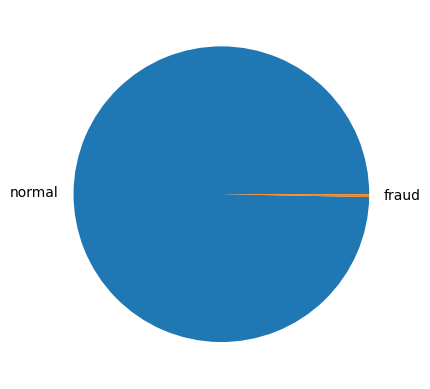

In [59]:
plt.pie(df['Class'].value_counts(),labels=['normal','fraud'])
plt.show

In [60]:
df[df['Class']==1]==0

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
623,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6108,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6329,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30442,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30473,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31002,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [61]:
f=df[df['Class']==1]


In [62]:
N=df[df['Class']==0]

In [63]:
df.shape

(33623, 31)

In [64]:
N.shape

(33519, 31)

In [65]:
f.shape

(103, 31)

In [66]:
normalsamples=N.sample(n=103)

In [67]:
newdf=pd.concat([normalsamples,f],ignore_index=True)

In [68]:
newdf.shape



(206, 31)

In [69]:
x=newdf.drop(['Class'],axis=1)

In [70]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,14988,-1.010979,0.956151,2.080257,0.287531,-0.531395,0.303162,2.224426,-0.731310,1.036223,...,-0.261404,-0.162913,0.198497,-0.293112,0.339782,0.412994,-0.514475,-0.408902,-0.478214,0.730629
1,36093,1.321500,-0.669446,0.199495,-0.610936,-0.832896,-0.578344,-0.415110,-0.201687,-0.634022,...,0.228698,-0.019044,-0.144988,-0.119102,-0.110225,0.544067,-0.276664,0.001427,0.021687,-0.055124
2,1900,0.333629,-1.016088,-0.090071,1.785491,-0.635735,-0.532212,0.834704,-0.257752,-0.078278,...,0.672214,0.289641,0.069849,-0.431615,0.664561,0.548023,-0.310990,-0.052639,0.090879,1.523656
3,36137,-2.147044,-1.279181,2.502243,-1.096769,-1.867312,0.888189,-1.200875,0.949790,0.227831,...,0.200140,0.365454,1.171846,-0.486273,0.100582,0.622118,0.019749,0.213144,-0.079951,0.404218
4,33001,-0.475068,0.451881,1.593759,0.704968,-0.105311,-0.256180,0.555362,0.044317,-0.211671,...,0.124280,-0.010955,0.059272,0.165970,0.442871,-0.579560,0.270265,0.131752,0.163132,-0.115324


In [73]:
y=newdf['Class']

In [71]:
from sklearn.model_selection import train_test_split

In [74]:
N_train,N_test,f_train,f_test=train_test_split(x,y,test_size=0.20,random_state=101)

In [76]:
model=RandomForestClassifier()

In [77]:
model.fit(N_train,f_train)

RandomForestClassifier()

In [78]:
f_pred=model.predict(N_test)


In [83]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(N_test)

In [84]:
accuracy=accuracy_score(f_test,y_pred)

In [85]:
accuracy

0.9285714285714286